In [1]:
import numpy as np
import matplotlib.pyplot as plt
from disba import PhaseDispersion, depthplot
import subfunctions as sf
from Least_squares import invert_dispersion_ls

# Reproducibility for synthetic noise
np.random.seed(42)

In [2]:
# Synthetic dispersion data generation

velocity_model = np.array([
    [20.0, 600.0,  300.0, 2000.0],
    [40.0, 1400.0,  700.0, 2000.0],
    [ 0.0, 2000.0, 1000.0, 2000.0],
]) * 1.0e-3  # convert from (m, m/s, m/s, kg/m^3) to (km, km/s, km/s, g/cc)-like scale

# Thickness array for plotting (use a dummy last layer thickness for depthplot)
thk_true = np.append(velocity_model[:-1, 0].copy(), 1.0)
vs_true  = velocity_model[:, 2].copy()

# Period sampling (s)
# Here we create frequencies 3~10 Hz and convert to periods (reversed)
f = np.linspace(1.0, 10.0, 20)     # Hz
periods = 1.0 / f[::-1]            # s (ascending)

pd = PhaseDispersion(*velocity_model.T)
cpr = pd(periods, mode=0, wave="rayleigh")

syn_period = cpr.period
syn_velocity = cpr.velocity + 0.01 * np.random.randn(len(cpr.velocity))  # add noise

`xtol` termination condition is satisfied.
Function evaluations 21, initial cost 4.6329e-02, final cost 4.3211e-02, first-order optimality 8.08e-01.

=== Inversion result ===
success: True
message: `xtol` termination condition is satisfied.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.01017193 0.0405854  0.19929024 0.59971173 1.09945931]

Inverted model [thk vp vs rho]:
 [[0.01017193 0.39858047 0.19929024 2.        ]
 [0.0405854  1.19942345 0.59971173 2.        ]
 [0.         2.19891862 1.09945931 2.        ]]


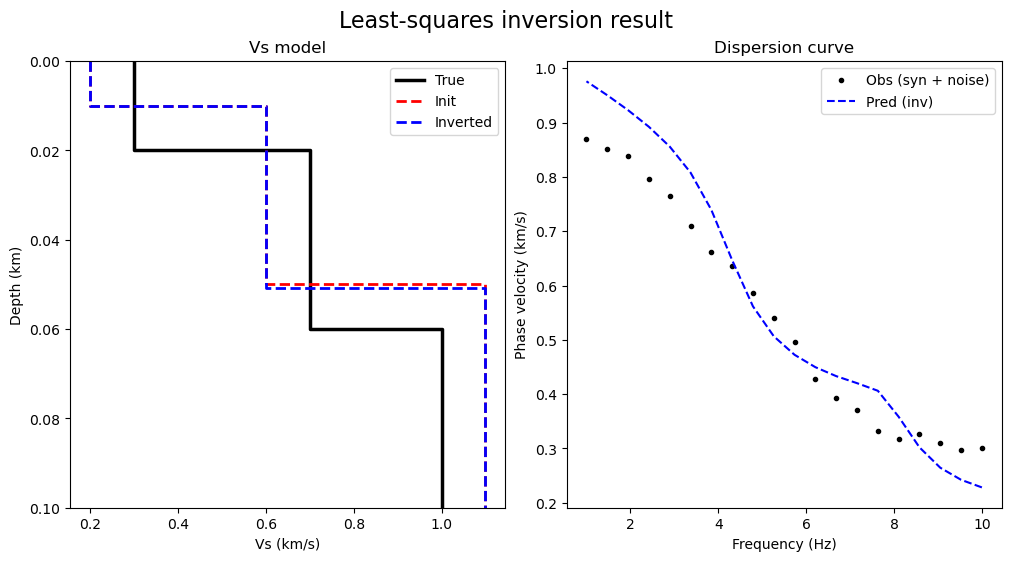

In [3]:
# An example of performing least-squares inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_ls(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
    method="trf",     # change to "lm" if you want (no bounds)
    verbose=1
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("Least-squares inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "r", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "r-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("ls_inversion_result.png", dpi=150)
plt.show()

Optimization terminated successfully.
         Current function value: 0.000883
         Iterations: 21
         Function evaluations: 27
         Gradient evaluations: 27

=== Inversion result ===
success: True
message: Optimization terminated successfully.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.02069689 0.04594091 0.30674586 0.72128945 0.9926852 ]

Inverted model [thk vp vs rho]:
 [[0.02069689 0.61349172 0.30674586 2.        ]
 [0.04594091 1.44257889 0.72128945 2.        ]
 [0.         1.9853704  0.9926852  2.        ]]


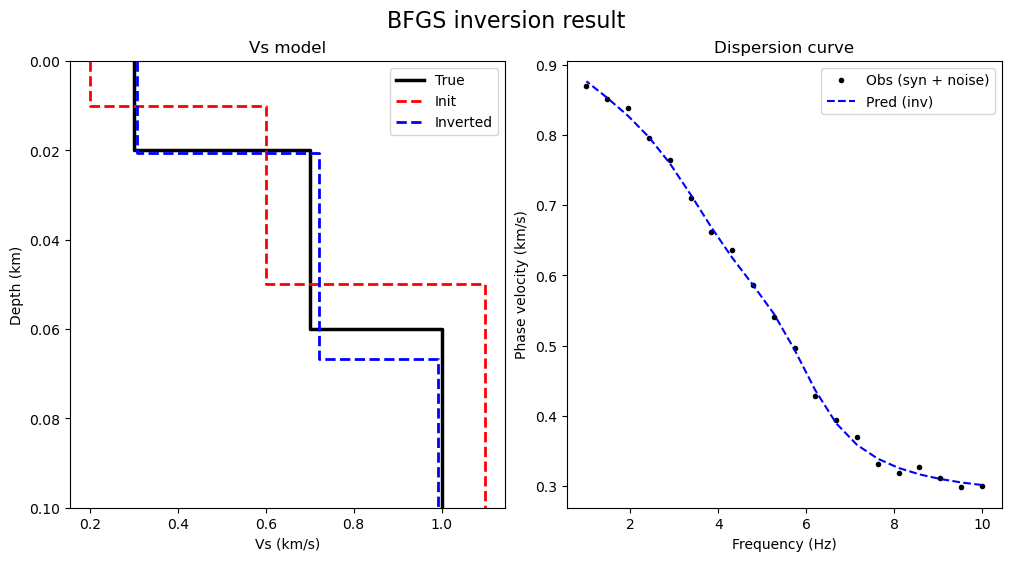

In [4]:
from BFGS import invert_dispersion_bfgs
# An example of performing least-squares inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_bfgs(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("BFGS inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "r", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "r-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("BFGS_inversion_result.png", dpi=150)
plt.show()